In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
merged=pd.read_csv("../Processed/merged.csv")

In [17]:
latest_season = merged['season'].max()
last_3_seasons = [latest_season - 2, latest_season - 1, latest_season]

df3 = merged[merged['season'].isin(last_3_seasons)]



In [18]:
retained_players = {
    # CSK
    'RD Gaikwad',
    'M Pathirana',
    'S Dube',
    'RA Jadeja',
    'MS Dhoni',

    # DC
    'AR Patel',
    'Kuldeep Yadav',
    'T Stubbs',
    'Abishek Porel',

    # GT
    'Rashid Khan',
    'Shubman Gill',
    'B Sai Sudharsan',
    'R Tewatia',
    'M Shahrukh Khan',

    # KKR
    'RK Singh',
    'CV Varun',
    'SP Narine',
    'AD Russell',
    'Harshit Rana',
    'Ramandeep Singh',

    # LSG
    'N Pooran',
    'Ravi Bishnoi',
    'Mayank Yadav',
    'Mohsin Khan',
    'A Badoni',

    # MI
    'JJ Bumrah',
    'SA Yadav',
    'HH Pandya',
    'RG Sharma',
    'Tilak Varma',

    # PBKS
    'Shashank Singh',
    'P Simran Singh',

    # RR
    'SV Samson',
    'YBK Jaiswal',
    'R Parag',
    'Dhruv Jurel',
    'SO Hetmyer',
    'Sandeep Sharma',

    # RCB
    'V Kohli',
    'RM Patidar',
    'Yash Dayal',

    # SRH
    'PJ Cummins',
    'Abhishek Sharma',
    'Nithish Kumar Reddy',
    'H Klaasen',
    'TM Head'
}


In [19]:
df_bat_auction = df3[~df3['batter'].isin(retained_players)].copy()


In [20]:
df_bowl_auction = df3[~df3['bowler'].isin(retained_players)].copy()


In [21]:
df_field_auction = df3[~df3['fielder'].isin(retained_players)].copy()


In [22]:
dismissals = df3[df3['player_dismissed'].notna()]
dismissals = dismissals[~dismissals['player_dismissed'].isin(retained_players)]


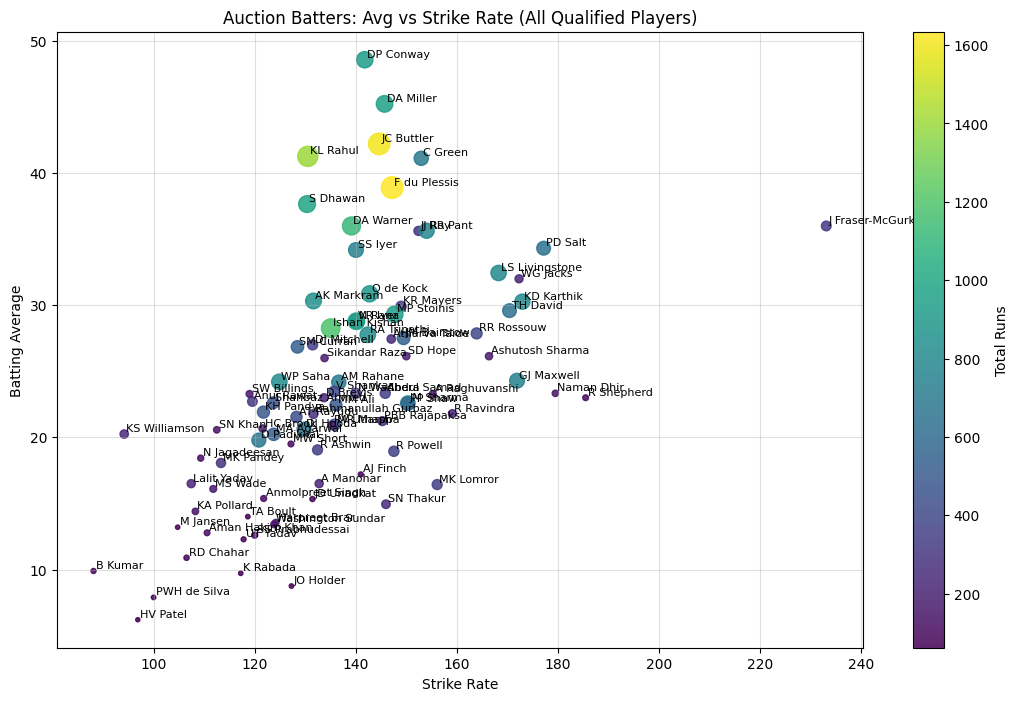

<Figure size 640x480 with 0 Axes>

In [23]:
df_bat_auction = df3[~df3['batter'].isin(retained_players)].copy()

legal_balls = df_bat_auction[~df_bat_auction['extras_type'].isin(['wides', 'noballs'])]

bat_runs = legal_balls.groupby('batter')['batsman_runs'].sum()
bat_balls = legal_balls.groupby('batter').size()
bat_outs = df_bat_auction[df_bat_auction['player_dismissed'].notna()].groupby('player_dismissed').size()

bat = pd.concat([bat_runs, bat_balls, bat_outs], axis=1)
bat.columns = ['runs', 'balls', 'outs']
bat = bat.dropna()

bat = bat[(bat['balls'] >= 50) & (bat['outs'] >= 5)]

bat['avg'] = bat['runs'] / bat['outs']
bat['sr'] = (bat['runs'] / bat['balls']) * 100

plt.figure(figsize=(13,8))

sc = plt.scatter(
    bat['sr'],
    bat['avg'],
    c=bat['runs'],
    s=bat['runs'] * 0.15,
    alpha=0.85
)

for player in bat.index:
    plt.text(
        bat.loc[player,'sr'] + 0.4,
        bat.loc[player,'avg'] + 0.2,
        player,
        fontsize=8
    )

plt.colorbar(sc, label='Total Runs')
plt.xlabel('Strike Rate')
plt.ylabel('Batting Average')
plt.title('Auction Batters: Avg vs Strike Rate (All Qualified Players)')
plt.grid(alpha=0.4)
plt.show()
plt.savefig('../Images/Batting_Selection(Avg vs SR).png', dpi=150, bbox_inches='tight')


In [24]:
df_bat_auction = df3[~df3['batter'].isin(retained_players)].copy()

df_bat_auction['is_legal_ball'] = ~df_bat_auction['extras_type'].isin(['wides', 'noballs'])
df_bat_auction['phase'] = pd.cut(
    df_bat_auction['over'],
    bins=[-1, 5, 14, 19],
    labels=['Powerplay', 'Middle', 'Death']
)

bat_phase = (
    df_bat_auction[df_bat_auction['is_legal_ball']]
    .groupby(['batter', 'phase'], as_index=False)
    .agg(
        runs=('batsman_runs', 'sum'),
        balls=('ball', 'count'),
        outs=('player_dismissed', lambda x: x.notna().sum())
    )
)

total_runs = bat_phase.groupby('batter', as_index=False)['runs'].sum()
total_runs.columns = ['batter', 'total_runs']

bat_phase = bat_phase.merge(total_runs, on='batter')
bat_phase['phase_pct'] = bat_phase['runs'] / bat_phase['total_runs']

role_map = (
    bat_phase.sort_values(['batter', 'phase_pct'], ascending=[True, False])
    .groupby('batter', as_index=False)
    .first()[['batter', 'phase']]
)

final = (
    bat_phase.groupby('batter', as_index=False)
    .agg(
        runs=('runs', 'sum'),
        balls=('balls', 'sum'),
        outs=('outs', 'sum')
    )
    .merge(role_map, on='batter')
)

final['avg'] = final['runs'] / final['outs'].replace(0, pd.NA)
final['sr'] = final['runs'] / final['balls'] * 100

final['role'] = final['phase'].map({
    'Powerplay': 'Openers',
    'Middle': 'Middle Order',
    'Death': 'Finishers'
})

final = final[(final['balls'] >= 120) & (final['runs'] >= 250)]
final['bat_score'] = final['avg'] * 0.6 + final['sr'] * 0.4

top_by_role = (
    final.sort_values(['role', 'bat_score'], ascending=[True, False])
    .groupby('role')
    .head(30)
)

for role, data in top_by_role.groupby('role'):
    print(f"\n=== {role} ===")
    print(data[['batter', 'runs', 'avg', 'sr', 'bat_score']].round(2))



=== Openers ===
                 batter  runs   avg      sr  bat_score
70      J Fraser-McGurk   324  2.33  233.09      94.64
153             PD Salt   652  1.77  177.17      71.93
78               JJ Roy   285  1.52  152.41      61.88
158             PP Shaw   586  1.50  150.26      61.00
79          JM Bairstow   550  1.49  149.46      60.68
96            KR Mayers   359  1.49  148.96      60.48
55         F du Plessis  1634  1.47  147.21      59.77
74           JC Buttler  1604  1.45  144.63      58.72
161           Q de Kock   895  1.43  142.74      57.95
45            DA Warner  1116  1.39  139.15      56.50
12            AM Rahane   701  1.37  136.65      55.48
128            MR Marsh   440  1.36  135.80      55.14
69         Ishan Kishan  1187  1.35  135.04      54.83
180  Rahmanullah Gurbaz   283  1.32  131.63      53.44
93             KL Rahul  1403  1.31  130.51      52.99
182            S Dhawan   979  1.30  130.36      52.93
226             WP Saha   823  1.25  124.89     

Openers To Target 

Jake Fraser-McGurk:-
Ultra-aggressive PP, breaks games early, forces field changes.

Phil Salt:-
Explosive + consistent, dominates Powerplay, quick starts.

Jos Buttler:-
Proven IPL match-winner, handles pressure, elite PP impact.

Faf du Plessis:-
High run volume, reliable starts, leadership value.

Quinton de Kock:-
Left-hand opener, steady + attacking option, wicketkeeping value.

Ishan Kishan:-
Indian aggressive opener, powerplay intent, marketable Indian core.

Jonny Bairstow:-
Strong vs pace, fast starter, overseas power option.

Prithvi Shaw:-
High PP SR, boundary-hitter, high risk–high reward

Middle Order Batsman to target

Glenn Maxwell:-
Spin basher, instant momentum, part-time bowling.

Liam Livingstone:-
Power vs spin, six-hitting threat, middle overs destroyer.

Cameron Green:-
Power + pace hitting, seam option, flexible batting slot.

Rishabh Pant:-
Left-hand disruptor, attacks spin, Indian middle-order core.

RR Rossouw:-
High SR vs pace, matchup hitter, accelerates middle phase.

Venkatesh Iyer:-
Left-hander, pace hitter, stabilizes with power.

Shreyas Iyer:-
Spin player, innings control, collapse management.

Marcus Stoinis:-
Floater role, power hitter, handles short bursts.

Finishers To Target

Dinesh Karthik:-
Best death-overs SR, proven role clarity, elite last-5 overs impact.

Tim David:-
Pure six-hitter, destroys pace at death, changes totals in 10 balls.

Rovman Powell:-
Strong vs pace, boundary-hitter, good secondary finisher.

Shivam Thakur:-
Indian finisher + bowling value, flexible lower-order hitter.

Abdul Samad:-
Raw power, impact-sub profile, upside pick for late overs.

David Miller:-
Experienced finisher, clutch ability, but declining peak — value buy only.

Anuj Rawat:-
Backup Indian option, low SR for finisher, squad depth only.